# Latent fields from many proxies

A recurring situation: some quantity varies across space or time, we cannot observe it directly, and
several different instruments each give a noisy, indirect view of it. A climate curve seen through both an
isotope record and a fossil assemblage; a pollution field seen through a handful of sensors and a
dispersion model; a demand surface seen through clicks and through sales. The honest thing is not to
analyze each proxy in isolation but to treat the hidden quantity as one latent field, hang every proxy's
forward model off it, and infer the field and all the nuisance parameters jointly. Because the proxies
share the field, combining them sharpens the posterior on all of them, and a posterior is then readable
off any node: the field itself or any proxy's parameters.

This notebook develops that pattern with `mixle.ppl.fit_field`. The organizing fact is that information
is additive: at the joint maximum a posteriori estimate the posterior precision of the field is the prior
precision plus each proxy's Fisher information, so each proxy's contribution can be read off separately.

## 1. The field and its prior

A latent field is a vector $f = (f_1, \dots, f_n)$ of values on an index grid (time bins, spatial
coordinates). We give it a Gaussian prior $f \sim \mathcal{N}(0, \Lambda^{-1})$ with precision matrix
$\Lambda$ supplied by a kernel. Two kernels cover most needs.

A Gaussian-Markov random field penalizes roughness through finite differences. The first-difference
prior has precision $\Lambda = D^\top D / s^2 + I/r^2$, where $D$ is the differencing matrix, $s$ the
smoothness scale, and the ridge $r$ makes the otherwise-improper prior proper by anchoring the level.
This is the discrete analogue of an integrated-noise (random-walk) process; using the second difference
penalizes curvature instead and gives a smoother, thin-plate-like field.

A squared-exponential (RBF) kernel instead specifies the covariance directly,
$K_{ij} = a^2 \exp(-\tfrac12 \lVert x_i - x_j\rVert^2 / \ell^2)$, and takes $\Lambda = (K + \epsilon I)^{-1}$.
Its index can be one-dimensional (a grid) or a matrix of coordinates, so the same object is a spatial-field
prior.

field of 60 nodes; prior precision is 60 x 60


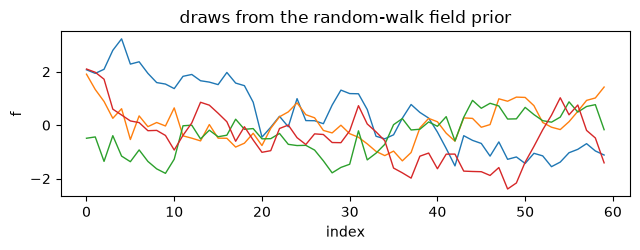

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.ppl import (GaussianField, RandomWalk, RBF, GaussianProxy, LogisticNicheProxy,
                      PoissonProxy, fit_field, GP, Gaussian, Niche, Cox, joint, free)

n = 60
field = GaussianField(index=np.arange(n), kernel=RandomWalk(scale=0.5, ridge=3.0), name="f")
print('field of %d nodes; prior precision is %d x %d' % (n, *field.precision.shape))
# a draw from the prior shows the smoothness the kernel encodes
chol = np.linalg.cholesky(np.linalg.inv(field.precision))
fig, ax = plt.subplots(figsize=(6.5, 2.6))
for s in range(4):
    ax.plot(np.arange(n), chol @ np.random.RandomState(s).randn(n), lw=1.0)
ax.set_title('draws from the random-walk field prior'); ax.set_xlabel('index'); ax.set_ylabel('f')
plt.tight_layout(); plt.show()

## 2. One proxy, and a check on the posterior

The simplest proxy is a linear-Gaussian forward model: $y_j \sim \mathcal{N}(a + b\, f_{j}, \sigma)$. With
the gain $b$, offset $a$ and noise $\sigma$ known, the model is fully Gaussian, so the posterior is exactly
Gaussian with precision $\Lambda + (b/\sigma)^2 \sum_j e_j e_j^\top$ and a mean given by the usual normal
equations. `fit_field` finds the joint maximum a posteriori estimate and reports the Laplace posterior,
the inverse of the negative-log-posterior Hessian at that point. When every factor is Gaussian the Laplace
posterior is not an approximation -- it is the exact posterior, which is a clean check on the machinery.

In [2]:
rng = np.random.RandomState(0)
f_true = chol @ rng.randn(n)
a, b, sig = 0.5, -1.3, 0.3
y = a + b * f_true + sig * rng.randn(n)

post = fit_field(field, [GaussianProxy(y, slope=b, intercept=a, scale=sig)], how="laplace")
mean, sd = post.posterior("f")

# closed-form Gaussian posterior, for comparison
prec = field.precision.copy(); np.fill_diagonal(prec, np.diag(prec) + (b/sig)**2)
cov = np.linalg.inv(prec); mean_cf = cov @ (b/sig**2 * (y - a)); sd_cf = np.sqrt(np.diag(cov))
print('max |mean - closed form| = %.2e' % np.max(np.abs(mean - mean_cf)))
print('max |sd   - closed form| = %.2e' % np.max(np.abs(sd - sd_cf)))

max |mean - closed form| = 1.83e-06
max |sd   - closed form| = 0.00e+00


## 3. Two proxies, and why combining them sharpens the field

Now hang a second, very different proxy off the same field. A common one is occupancy: a collection of
indicator series, each present where the field is near that indicator's preferred value. Concretely, item
$i$ is present at node $t$ with probability $\operatorname{sigmoid}(\beta - \tfrac12 \kappa_i (f_t -
\mu_i)^2)$, a unimodal response peaked at its optimum $\mu_i$ with width set by $\kappa_i$. The assemblage
of items acts as a thermometer for the field even though no single one observes it directly.

Fitting both proxies together is one optimization over the field, the forward-model coefficients, and all
the niche parameters. Because information is additive, the field's posterior precision under any subset of
proxies is the prior precision plus those proxies' Fisher information blocks, all evaluated at the one
joint estimate. So we can read the field posterior under the Gaussian proxy alone, under the occupancy
proxy alone, and under both, without refitting -- and the joint is no wider than either, anywhere.

79 of 80 taxa carry enough detections to identify a niche width


Gaussian proxy only    median posterior sd 0.197
occupancy proxy only   median posterior sd 0.313
joint                  median posterior sd 0.122
joint is tighter than each proxy everywhere: True


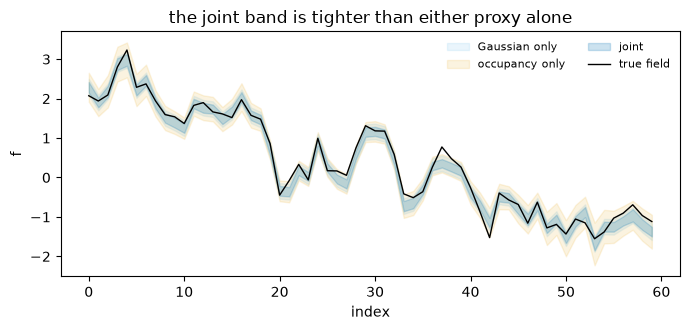

In [3]:
S = 80
mu = rng.uniform(f_true.min(), f_true.max(), S)
kappa = np.exp(rng.uniform(-0.5, 1.5, S))
logit = 1.0 - 0.5 * kappa[:, None] * (f_true[None, :] - mu[:, None])**2
presence = (rng.rand(S, n) < 1/(1 + np.exp(-logit))).astype(float)

# A unimodal niche has a LOCATION and a WIDTH, and a width needs detections on both shoulders of
# the response to be identified at all. A taxon seen in only a handful of bins pins neither, and
# its log-kappa becomes an exactly flat direction in the joint curvature -- which is what the
# Laplace approximation reports when it refuses to invert a singular Hessian. (mu is regularized by
# the proxy's mu_scale; kappa is not, so nothing else picks up the slack.) Keep the taxa the
# assemblage can actually speak for.
detections = presence.sum(axis=1)
informative = (detections >= 5) & (detections <= n - 5)
print(f'{int(informative.sum())} of {S} taxa carry enough detections to identify a niche width')
presence, mu, kappa = presence[informative], mu[informative], kappa[informative]
S = int(informative.sum())

post = fit_field(field,
                 [GaussianProxy(y, slope=b, intercept=a, scale=sig), LogisticNicheProxy(presence)],
                 how="laplace", max_iter=400)
_, sd_gauss = post.field_posterior(include=["gauss"])
_, sd_niche = post.field_posterior(include=["niche"])
f_map, sd_joint = post.field_posterior()
for label, s in [("Gaussian proxy only", sd_gauss), ("occupancy proxy only", sd_niche), ("joint", sd_joint)]:
    print('%-22s median posterior sd %.3f' % (label, np.median(s)))
print('joint is tighter than each proxy everywhere:',
      bool(np.all(sd_joint <= sd_gauss + 1e-9) and np.all(sd_joint <= sd_niche + 1e-9)))

fig, ax = plt.subplots(figsize=(7.0, 3.4))
x = np.arange(n)
for label, s, c in [("Gaussian only", sd_gauss, "#56B4E9"), ("occupancy only", sd_niche, "#E69F00"),
                    ("joint", sd_joint, "#0072B2")]:
    ax.fill_between(x, f_map - s, f_map + s, color=c, alpha=0.20 if label == "joint" else 0.12, label=label)
ax.plot(x, f_true, color="k", lw=1.0, label="true field")
ax.set_xlabel('index'); ax.set_ylabel('f'); ax.set_title('the joint band is tighter than either proxy alone')
ax.legend(fontsize=8, frameon=False, ncol=2); plt.tight_layout(); plt.show()

## 4. A posterior over any node

The point of one joint inference is that every unknown gets a posterior on the same footing. The field is
one node; each proxy's parameters are others. `summary()` returns the posterior mean and standard
deviation for all of them, and `posterior(node)` returns any single one. The occupancy optima $\mu_i$, for
instance, are recovered with their own uncertainty.

In [4]:
summ = post.summary()
print('nodes with posteriors:', list(summ))
mu_mean, mu_sd = post.posterior("niche.mu")
ok = np.abs(mu_mean - mu) < 2 * mu_sd
print('recovered niche optima within 2 sd of truth: %d of %d' % (ok.sum(), S))

nodes with posteriors: ['f', 'niche.mu', 'niche.logkappa', 'niche.b']
recovered niche optima within 2 sd of truth: 66 of 79


## 5. A latent intensity: the log-Gaussian Cox process

When the proxy is a count rather than a measurement, the natural forward model is Poisson with a
log-intensity that is the latent field: $\text{count}_j \sim \text{Poisson}(\exp(o_j + f_j))$, with $o$ a
known offset. This is the log-Gaussian Cox process -- a doubly stochastic Poisson process whose rate is a
smooth random field -- and it is the same machinery with a Poisson proxy. It recovers a smoothly varying
intensity from noisy counts, with uncertainty.

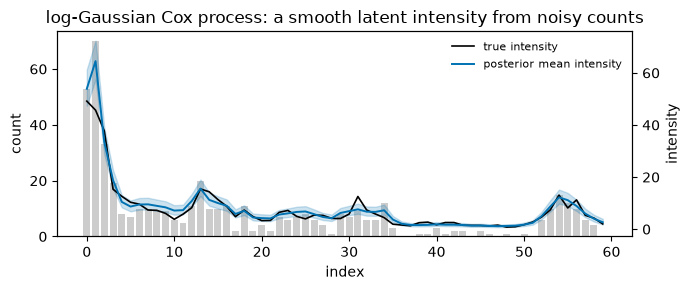

corr(posterior log-intensity, truth) = 0.957


In [5]:
field_c = GaussianField(np.arange(n), RandomWalk(scale=0.4, ridge=3.0), name="logmu")
chol_c = np.linalg.cholesky(np.linalg.inv(field_c.precision))
log_intensity = chol_c @ np.random.RandomState(3).randn(n)
offset = 2.0
counts = np.random.RandomState(4).poisson(np.exp(offset + log_intensity))
post_c = fit_field(field_c, [PoissonProxy(counts, offset=offset)], how="laplace", max_iter=400)
g_map, g_sd = post_c.posterior("logmu")

fig, ax = plt.subplots(figsize=(7.0, 3.0))
x = np.arange(n)
ax.bar(x, counts, color="#cccccc", label="observed counts")
ax2 = ax.twinx()
ax2.plot(x, np.exp(offset + log_intensity), color="k", lw=1.2, label="true intensity")
ax2.plot(x, np.exp(offset + g_map), color="#0072B2", lw=1.4, label="posterior mean intensity")
ax2.fill_between(x, np.exp(offset + g_map - g_sd), np.exp(offset + g_map + g_sd), color="#0072B2", alpha=0.2)
ax.set_xlabel('index'); ax.set_ylabel('count'); ax2.set_ylabel('intensity')
ax.set_title('log-Gaussian Cox process: a smooth latent intensity from noisy counts')
ax2.legend(fontsize=8, frameon=False, loc='upper right'); plt.tight_layout(); plt.show()
print('corr(posterior log-intensity, truth) = %.3f' % np.corrcoef(g_map, log_intensity)[0, 1])

## 6. Identifiability, and why it is not a bug

Latent-field models have genuine gauge freedoms, and it is better to know them than to be surprised. Two
appear above. First, if the Gaussian proxy's gain $b$ is left free while the field has a zero-mean prior,
the likelihood is unchanged under $b \mapsto cb,\ f \mapsto f/c$, and the prior, which penalizes large $f$,
drives $f \to 0$ and $b \to \infty$: the scale is not identified. Fixing the gain to its known
forward-model value (a calibration constant) removes the degeneracy. Second, the occupancy and Gaussian
forward models are symmetric under $f \mapsto -f$ with the niche optima and the gain flipping sign, so the
field is identified only up to sign, and only up to an overall level that the offset can absorb. One
anchors the sign with a known gain direction and the level with the ridge.

These are the same identifiability and gauge-fixing concerns that arise in any joint latent-variable model;
the field machinery does not hide them. A posterior that is wide because a proxy is uninformative, or
because a direction is unidentified, is the correct answer, not a failure.

## 7. Writing the forward model as an equation

The explicit form above passes proxy objects with their coefficients. There is also an equation-style
surface: a field is a `GP` node, a linear forward model is written as arithmetic in it, and `joint`
discovers the shared field and fits it. The two are the same computation -- the equation form delegates to
`fit_field` -- so it is purely a matter of which reads better for a given model.

In [6]:
T = GP("f", index=np.arange(n), kernel=RandomWalk(scale=0.5, ridge=3.0))
post_eq = joint([
    Gaussian(y, mean=a + b * T, sd=sig),   # the forward model, as an equation
    Niche(presence, over=T),
]).fit(how="laplace", max_iter=400)
_, sd_eq = post_eq.field_posterior()
print('equation-style and explicit posteriors agree:', bool(np.allclose(sd_eq, sd_joint, atol=1e-8)))

equation-style and explicit posteriors agree: True


## In short

- A quantity seen through several indirect, noisy proxies is best treated as one latent field with a
  Gaussian-process or Gaussian-Markov-random-field prior, with every proxy's forward model hung off it and
  inferred jointly.
- Information is additive: at the joint estimate the field's posterior precision is the prior precision
  plus each proxy's Fisher information, so combining proxies sharpens the field and each contribution is
  separable.
- The same machinery covers measurements (Gaussian forward model), occupancy (logistic niches), and counts
  (the log-Gaussian Cox process), and a posterior is readable off any node.
- Latent-field models carry real gauge freedoms; anchor the gain and the level, and read wide posteriors as
  honest statements about what the data does not determine.

## References

- Rue, H. & Held, L. (2005). Gaussian Markov Random Fields: Theory and Applications. Chapman and Hall/CRC.
- Williams, C. K. I. & Rasmussen, C. E. (2006). Gaussian Processes for Machine Learning. MIT Press.
- Moller, J., Syversveen, A. R. & Waagepetersen, R. P. (1998). Log Gaussian Cox processes. Scandinavian Journal of Statistics, 25(3), 451-482.
- Banerjee, S., Carlin, B. P. & Gelfand, A. E. (2014). Hierarchical Modeling and Analysis for Spatial Data (2nd ed.). Chapman and Hall/CRC.

## Exercises and extensions

1. Calibration of the Laplace posterior. For the pure-Gaussian model of Section 2, draw the true field from
   the prior and check that a 95% interval covers the truth about 95% of the time across many simulations.
   Then misspecify the smoothness scale and show how coverage degrades.
2. Value of a proxy. For the two-proxy model, vary the number of occupancy items and plot the median joint
   posterior standard deviation against it. How many items are worth one Gaussian measurement per node?
3. Spatial field. Replace the one-dimensional grid with two-dimensional coordinates and an RBF kernel, place
   a handful of Gaussian sensors, and map the posterior mean and standard deviation surfaces.
4. Cox process with covariates. Add a known per-node offset (a log-exposure or a covariate effect) to the
   Poisson proxy and confirm the latent field recovers only the residual log-intensity.
5. Second-difference prior. Refit Section 3 with `RandomWalk(order=2)` and compare the recovered field and
   its uncertainty to the first-difference prior; relate the difference to the smoothness each prior assumes.